<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L2_Soft_and_Hard_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=xuPite2wb8Q) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P02.pdf)

In [1]:
# Week 8, Lecture 2: Soft and Hard Attention
from IPython.display import HTML, display

VIDEO_ID = "xuPite2wb8Q"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 2: Vision and Language — Image Captioning

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.2 Image Captioning**.

**What you will learn**

- How a CNN and an RNN are wired together to describe an image, and where the image enters.
- Attention over a feature grid: $z_t = \sum_i a_i v_i$, with $L$ annotation vectors of width $D$.
- **Soft versus hard** attention: the expectation identity that connects them, and why only one is differentiable.
- Where else the image can be injected — the LSTM-A family of five variants.
- **StyleNet**'s factored LSTM, and how swapping one factor changes the caption's style.

**Contents**

1. Captioning without attention
2. Attention over a feature grid
3. Soft and hard attention
4. Where to inject the image: LSTM-A
5. StyleNet and the factored LSTM
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture replaced the single fixed-length context vector with a per-step
context $c_t = \sum_j \alpha_{t,j} h_j$, and showed how an $m \times n \times c$ CNN volume
becomes $mn$ annotation vectors to attend over. This lecture puts that to work on the task
it was invented for.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Captioning without attention

Karpathy et al. (CVPR 2015) take a VGG-16, delete the 1000-way classifier, and use the
4096-dimensional activation as the image representation $v$. The image enters the RNN
exactly once, by modifying the **first** hidden state:

$$\text{before:}\quad h_0 = \max(0,\; W_{xh} \ast x_0)$$
$$\text{now:}\quad h_0 = \max(0,\; W_{xh} \ast x_0 + W_{ih} \ast v)$$

After that the recurrence proceeds as usual, one word at a time, starting from `<START>`
and ending at `<END>`.

In [3]:
# The image-injection identity, and the property that makes it a ReLU state.
D_img, D_emb, Hh = 4096, 256, 512

W_xh = torch.randn(Hh, D_emb) * 0.02
W_ih = torch.randn(Hh, D_img) * 0.02
x0 = torch.randn(D_emb)                       # the <START> token embedding
v = torch.randn(D_img)                        # the 4096-d image vector

h0_with = torch.relu(W_xh @ x0 + W_ih @ v)
h0_without = torch.relu(W_xh @ x0)

# With no image (v = 0) the modified form collapses to the original.
assert torch.allclose(torch.relu(W_xh @ x0 + W_ih @ torch.zeros(D_img)), h0_without)
assert (h0_with >= 0).all(), 'a ReLU state must be non-negative'
frac_changed = (h0_with != h0_without).float().mean()

print(f'  image vector v: {D_img}-d (VGG-16 with the 1000-way classifier removed)')
print(f'  h0 without image: {h0_without.norm():.3f}   with image: {h0_with.norm():.3f}')
print(f'  {100 * frac_changed:.0f}% of the {Hh} hidden units changed when the image was injected')
print('  setting v = 0 recovers the original recurrence exactly')

  image vector v: 4096-d (VGG-16 with the 1000-way classifier removed)
  h0 without image: 4.340   with image: 19.296
  71% of the 512 hidden units changed when the image was injected
  setting v = 0 recovers the original recurrence exactly


## 2. Attention over a feature grid

Xu et al. (ICML 2015) keep the spatial grid instead of collapsing it. The CNN produces
$L$ annotation vectors of width $D$, where $L = W \times H$ is the number of spatial
locations. At every step the decoder emits a **distribution over the $L$ locations**, and
the context is their weighted combination:

$$z_t = \sum_{i=1}^{L} a_i\, v_i$$

The decoder state then emits two heads: the next attention distribution, and a distribution
over the vocabulary.

*A notation warning.* The slides write $a$ for the attention weights and $v$ for the
annotation vectors. The credited paper uses the opposite convention — $a_i$ are the
annotations there. Read carefully when moving between the two.

In [4]:
# The captioning attention step, with the shapes the slides give.
W_grid, H_grid, D_ann = 14, 14, 512
L = W_grid * H_grid                            # "Features: L x D, where L = W x H"
assert L == 196

V_ann = torch.randn(L, D_ann)                  # the annotation vectors v_1 ... v_L
h_dec = torch.randn(D_ann)

a = torch.softmax(V_ann @ h_dec, dim=0)        # "Distribution over L locations"
z = (a[:, None] * V_ann).sum(0)                # z_t = sum_i a_i v_i

assert a.shape == (L,) and z.shape == (D_ann,)
assert torch.allclose(a.sum(), torch.tensor(1.0), atol=1e-6)
assert torch.allclose(z, a @ V_ann, atol=1e-5)

vocab = 10000
d_vocab = torch.softmax(torch.randn(vocab), dim=0)
assert torch.allclose(d_vocab.sum(), torch.tensor(1.0), atol=1e-5)

print(f'  14 x 14 feature map -> L = {L} annotation vectors of width D = {D_ann}')
print(f'  attention a: {tuple(a.shape)}, sums to {a.sum():.4f}   ("distribution over L locations")')
print(f'  context  z: {tuple(z.shape)}                        ("weighted features: D")')
print(f'  vocab head: {tuple(d_vocab.shape)}, sums to {d_vocab.sum():.4f}  ("distribution over vocab")')

  14 x 14 feature map -> L = 196 annotation vectors of width D = 512
  attention a: (196,), sums to 1.0000   ("distribution over L locations")
  context  z: (512,)                        ("weighted features: D")
  vocab head: (10000,), sums to 1.0000  ("distribution over vocab")


## 3. Soft and hard attention

The slides show soft and hard attention as two pictures — diffuse grey blobs versus a single
sharp spot — but do not define them symbolically. Lecture 1 of this week gives the
definitions, so we use those:

- **soft**: every location gets a partial weight in $(0,1)$; deterministic, differentiable.
- **hard**: one location is chosen with weight 1.0; stochastic, non-differentiable.

The two are connected by an expectation. If $s_t$ is a one-hot vector sampled from the
distribution $a$, then

$$\mathbb{E}[\hat z_t] = \mathbb{E}\left[\sum_i s_{t,i} v_i\right] = \sum_i a_i v_i = z_t$$

so **hard attention is an unbiased estimator of soft attention**. That is checkable by
Monte Carlo.

In [5]:
# Hard attention is unbiased for soft attention: verify by sampling.
torch.manual_seed(0)
L_small, D_small = 16, 8
V_s = torch.randn(L_small, D_small)
a_s = torch.softmax(torch.randn(L_small), dim=0)

z_soft = a_s @ V_s                             # the deterministic weighted average

for n_samples in (10, 100, 1000, 10000, 100000):
    idx = torch.multinomial(a_s, n_samples, replacement=True)
    z_hard_mean = V_s[idx].mean(0)             # average of the sampled one-hot picks
    err = (z_hard_mean - z_soft).norm() / z_soft.norm()
    print(f'  {n_samples:6d} hard samples -> relative error vs soft attention {err:.4f}')

idx = torch.multinomial(a_s, 200000, replacement=True)
assert (V_s[idx].mean(0) - z_soft).norm() / z_soft.norm() < 0.02, 'hard attention is not unbiased'
print('\n  the sample mean converges to the soft context vector, as the expectation predicts')

      10 hard samples -> relative error vs soft attention 0.6982
     100 hard samples -> relative error vs soft attention 0.1396
    1000 hard samples -> relative error vs soft attention 0.1302
   10000 hard samples -> relative error vs soft attention 0.0339
  100000 hard samples -> relative error vs soft attention 0.0087

  the sample mean converges to the soft context vector, as the expectation predicts


In [6]:
# But only one of them lets a gradient through.
a_logits = torch.randn(L_small, requires_grad=True)

soft_z = torch.softmax(a_logits, dim=0) @ V_s
soft_z.sum().backward()
print(f'  soft attention : gradient w.r.t. the attention logits, norm = {a_logits.grad.norm():.4f}')

a_logits.grad = None
with torch.no_grad():
    pick = torch.multinomial(torch.softmax(a_logits, dim=0), 1)
hard_z = V_s[pick].squeeze(0)
print(f'  hard attention : sampled context requires_grad = {hard_z.requires_grad}')
print('\n  soft attention trains by ordinary backpropagation;')
print('  hard attention needs an estimator that the slides do not cover')

  soft attention : gradient w.r.t. the attention logits, norm = 0.9123
  hard attention : sampled context requires_grad = False

  soft attention trains by ordinary backpropagation;
  hard attention needs an estimator that the slides do not cover


## 4. Where to inject the image: LSTM-A

Yao et al. (ICCV 2017) ask a simpler question: the image and a set of detected **attributes**
are both available, so where in the sequence should each be fed? They enumerate five
answers, with $\mathbf{I}$ the image vector and $\mathbf{A}$ the attribute vector:

| Variant | Injection |
|---|---|
| **A1** | attributes at $t = -1$, nothing else |
| **A2** | image at $t=-2$, then attributes at $t=-1$ |
| **A3** | attributes at $t=-2$, then image at $t=-1$ |
| **A4** | attributes at $t=-1$, image added at **every** step |
| **A5** | image at $t=-1$, attributes added at **every** step |

The reported ordering is A3 > A2 > A1 > baseline, A4 < A3, and A5 > A3. The slides explain
A4's failure as noise in the image accumulating when it is injected repeatedly.

In [7]:
# The five variants as input schedules. Only the schedule differs.
D_v, D_a, D_s, Hh2 = 1024, 256, 300, 512
T_cap = 6

T_v = torch.randn(Hh2, D_v) * 0.02             # image projection
T_a = torch.randn(Hh2, D_a) * 0.02             # attribute projection
T_s = torch.randn(Hh2, D_s) * 0.02             # word projection

I = torch.randn(D_v); A = torch.randn(D_a)
words = torch.randn(T_cap, D_s)

def schedule(variant):
    """Return the list of LSTM inputs, in order, for one variant."""
    pre, per_step = [], torch.zeros(Hh2)
    if variant == 'A1': pre = [T_a @ A]
    elif variant == 'A2': pre = [T_v @ I, T_a @ A]
    elif variant == 'A3': pre = [T_a @ A, T_v @ I]
    elif variant == 'A4': pre, per_step = [T_a @ A], T_v @ I
    elif variant == 'A5': pre, per_step = [T_v @ I], T_a @ A
    return pre + [T_s @ w + per_step for w in words]

for v_ in ('A1', 'A2', 'A3', 'A4', 'A5'):
    seq = schedule(v_)
    extra = len(seq) - T_cap
    repeated = 'yes' if v_ in ('A4', 'A5') else 'no '
    print(f'  {v_}: {len(seq)} inputs ({extra} before the first word), repeated injection: {repeated}')

assert len(schedule('A1')) == T_cap + 1
assert len(schedule('A2')) == len(schedule('A3')) == T_cap + 2
print('\n  A2 and A3 feed the same two vectors and differ only in ORDER,')
print('  yet the slides report A3 > A2 - the order of injection matters')

  A1: 7 inputs (1 before the first word), repeated injection: no 
  A2: 8 inputs (2 before the first word), repeated injection: no 
  A3: 8 inputs (2 before the first word), repeated injection: no 
  A4: 7 inputs (1 before the first word), repeated injection: yes
  A5: 7 inputs (1 before the first word), repeated injection: yes

  A2 and A3 feed the same two vectors and differ only in ORDER,
  yet the slides report A3 > A2 - the order of injection matters


## 5. StyleNet and the factored LSTM

Gan et al. (CVPR 2017) want captions in a *style* — factual, romantic, humorous. Their trick
is to factor each input-to-hidden matrix into three:

$$\mathbf{W}_x = \mathbf{U}_x \mathbf{S}_x \mathbf{V}_x$$

Then $\mathbf{U}$ and $\mathbf{V}$ are shared across all styles and trained on factual data,
while only the middle factor $\mathbf{S}_x$ is style-specific. At test time you **swap
$\mathbf{S}_x$** to change the style, leaving everything else fixed.

*A note on the slide's LSTM.* It prints $h_t = o_t \odot c_t$, without the $\tanh$ — while the
figure on the same slide clearly routes $c_t$ through a $\tanh$ first. The standard LSTM,
and Week 7 Lecture 3, use $h_t = o_t \odot \tanh(c_t)$.

In [8]:
# The factored matrix, and what swapping S alone does.
d_in, d_out, rank = 300, 512, 64

U = torch.randn(d_out, rank) * 0.05
V = torch.randn(rank, d_in) * 0.05
S_factual  = torch.randn(rank, rank) * 0.05
S_romantic = torch.randn(rank, rank) * 0.05

W_factual  = U @ S_factual  @ V
W_romantic = U @ S_romantic @ V
assert W_factual.shape == (d_out, d_in) == W_romantic.shape

x = torch.randn(d_in)
diff = (W_factual @ x - W_romantic @ x).norm() / (W_factual @ x).norm()
assert diff > 0.1, 'swapping S should change the output'

dense = d_out * d_in
factored_shared = U.numel() + V.numel()
per_style = S_factual.numel()

print(f'  dense W          : {dense:,} parameters')
print(f'  factored U, V    : {factored_shared:,} shared across every style')
print(f'  one S per style  : {per_style:,}')
print(f'\n  three styles cost {factored_shared + 3 * per_style:,} factored'
      f' vs {3 * dense:,} dense ({3 * dense / (factored_shared + 3 * per_style):.1f}x saving)')
print(f'  swapping S alone changes the output by {100 * diff:.0f}%')

  dense W          : 153,600 parameters
  factored U, V    : 51,968 shared across every style
  one S per style  : 4,096

  three styles cost 64,256 factored vs 460,800 dense (7.2x saving)
  swapping S alone changes the output by 131%


## 6. Explore and verify

The claims worth checking are the ones that hold exactly: that the context vector is a
convex combination of the annotations, and that hard attention is unbiased for soft.

In [9]:
# Verify the properties of the captioning attention.

# 1. The context vector is a convex combination, so it lies inside the convex hull.
a_test = torch.softmax(torch.randn(L), dim=0)
z_test = a_test @ V_ann
lo, hi = V_ann.min(0).values, V_ann.max(0).values
assert (z_test >= lo - 1e-4).all() and (z_test <= hi + 1e-4).all(), 'context escaped the hull'

# 2. Uniform attention gives exactly the mean annotation - the no-attention baseline.
uniform = torch.full((L,), 1.0 / L)
assert torch.allclose(uniform @ V_ann, V_ann.mean(0), atol=1e-5)

# 3. A one-hot (hard) attention returns exactly one annotation vector, unchanged.
onehot = torch.zeros(L); onehot[42] = 1.0
assert torch.allclose(onehot @ V_ann, V_ann[42], atol=1e-6)

print(f'  context vector lies within the annotation hull        ok')
print(f'  uniform attention == mean annotation (no attention)   ok')
print(f'  one-hot attention == a single annotation, unchanged   ok')
print(f'\n  so attention interpolates between "look everywhere" and "look at one patch";')
print(f'  entropy of uniform over L={L} is log(L) = {np.log(L):.3f} nats')

  context vector lies within the annotation hull        ok
  uniform attention == mean annotation (no attention)   ok
  one-hot attention == a single annotation, unchanged   ok

  so attention interpolates between "look everywhere" and "look at one patch";
  entropy of uniform over L=196 is log(L) = 5.278 nats


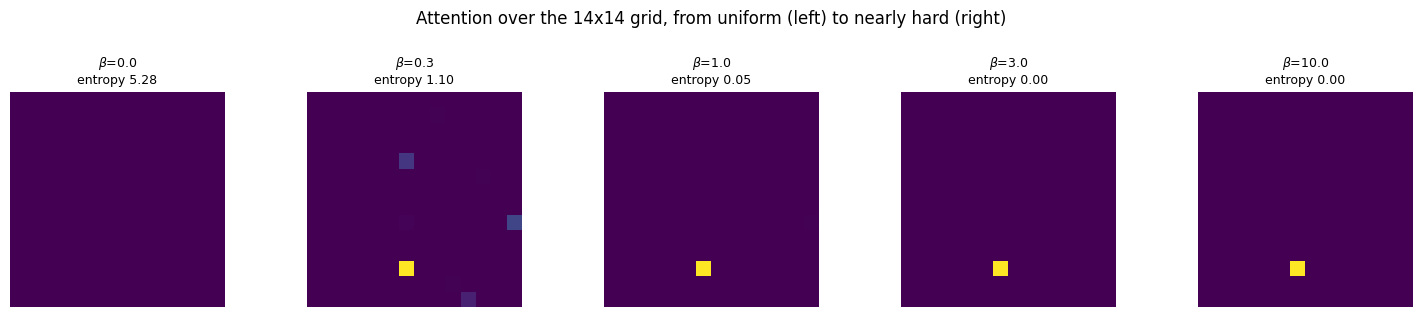

In [10]:
# Static sweep: attention entropy from fully peaked to fully uniform, on a 14x14 grid.
fig, ax = plt.subplots(1, 5, figsize=(15, 3.0))
base = (V_ann @ torch.randn(D_ann))
for a_, beta in zip(ax, [0.0, 0.3, 1.0, 3.0, 10.0]):
    w = torch.softmax(beta * base, dim=0)
    ent = -(w * (w + 1e-12).log()).sum()
    a_.imshow(w.reshape(W_grid, H_grid), cmap='viridis')
    a_.set_axis_off()
    a_.set_title(f'$\\beta$={beta}\nentropy {ent:.2f}', fontsize=9)
fig.suptitle('Attention over the 14x14 grid, from uniform (left) to nearly hard (right)', y=1.04)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [11]:
# Live: sharpen the attention map and watch the context vector move.
from ipywidgets import interact, FloatSlider

def attend(beta=1.0):
    w = torch.softmax(beta * base, dim=0)
    z_ = w @ V_ann
    ent = -(w * (w + 1e-12).log()).sum()
    dist_to_mean = (z_ - V_ann.mean(0)).norm()
    fig, ax_ = plt.subplots(1, 2, figsize=(9, 3.4))
    ax_[0].imshow(w.reshape(W_grid, H_grid), cmap='viridis'); ax_[0].set_axis_off()
    ax_[0].set_title(f'attention map, entropy {ent:.2f} nats')
    ax_[1].bar(range(40), z_[:40].numpy(), color='steelblue')
    ax_[1].set_title(f'context vector (first 40 dims)\ndistance from mean annotation {dist_to_mean:.2f}')
    plt.tight_layout(); plt.show()

interact(attend, beta=FloatSlider(min=0.0, max=10.0, step=0.25, value=1.0));

interactive(children=(FloatSlider(value=1.0, description='beta', max=10.0, step=0.25), Output()), _dom_classes…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Karpathy et al.** | Drop VGG's classifier, inject the 4096-d image once: $h_0 = \max(0, W_{xh}x_0 + W_{ih}v)$ |
| **Xu et al.** | Keep the spatial grid: $L = W \times H$ annotations of width $D$; $14\times14 \Rightarrow L = 196$ |
| **The context** | $z_t = \sum_i a_i v_i$ — a convex combination, so it lies inside the hull of the annotations |
| **Two heads** | The decoder emits a distribution over $L$ locations *and* a distribution over the vocabulary |
| **Soft vs hard** | Hard attention is an **unbiased estimator** of soft attention, but only soft admits a gradient |
| **LSTM-A** | Five injection schedules; A2 and A3 differ only in order, yet A3 wins |
| **StyleNet** | $W_x = U_x S_x V_x$; share $U, V$, swap only $S_x$ to change style |

## Exercises

1. **The homework from the slides.** Can we do the opposite — caption to image? Sketch what would have to change, and say which component of the pipeline has no obvious inverse.
2. **Attention as a convex combination.** Show that no setting of the attention weights can produce a context vector outside the convex hull of the annotations. What does that imply about what attention can and cannot represent?
3. **How many samples?** Section 3 showed hard attention is unbiased. Measure how the variance of the estimate falls with the number of samples, and work out how many you would need for a 1% error.
4. **A4 versus A3.** The slides blame A4's weaker performance on image noise accumulating when injected at every step. Add noise to `I` in the `schedule` function and measure how the accumulated perturbation grows for A4 against A3.
5. **The missing tanh.** The StyleNet slide prints $h_t = o_t \odot c_t$ while its figure shows a $\tanh$. Implement both, run them for 50 steps, and show which one keeps the hidden state bounded.
